<a href="https://colab.research.google.com/github/cesaryuri/Desafio-Analise-de-Dados-MCONF/blob/main/Desafio_Analise_MCONF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Metodologia de Análise de Dados

1. **Análise Exploratória (EDA):** Inspeção inicial para compreender a estrutura, os tipos e a distribuição dos dados brutos.
2. **Limpeza e Modelagem:** Tratamento de inconsistências e integração das tabelas utilizando consultas SQL (Joins).
3. **Auditoria de Qualidade:** Validação das taxas de correspondência nos cruzamentos para garantir a confiabilidade da base.
4. **Análise de Penetração:** Avaliação do alcance de mercado cruzando a base de clientes com dados demográficos externos (IBGE).
5. **Visualização e Exploração:** Criação de mapas geoespaciais e gráficos estratégicos para orientar a tomada de decisão da diretoria.


Importar pacotes necessários:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import unicodedata
import kagglehub
import folium
import duckdb
import os


# Tarefa 1: Análise exploratória

## Base de Dados Olist


> Analisando a base Olist, mostra que existem 99.441 pedidos únicos. Ao comparar o total de transações com os 96.096 clientes únicos, fica evidente que cerca de 3.300 clientes realizaram outros pedidos na plataforma. Essa informação foi extraída através da contagem de valores distintos entre as colunas de identificação de pedido e de cliente.

> Em termos de qualidade dos dados, a tabela de clientes não possui nulos, mas a de pedidos apresenta 2.965 registros sem data de entrega. Esse volume representa pacotes que tiveram algum impedimento, um dado obtido pela soma de valores ausentes nas colunas de data. Geograficamente, o estado de São Paulo domina o volume de vendas, representando quase metade da base, conforme apontado pela frequência de registros no resumo estatístico das colunas de texto.

> O ponto mais crítico está na geolocalização. A base contém mais de 1 milhão de linhas, mas apresenta 8.011 nomes de cidades únicos, um número muito superior aos 5.570 municípios reais do Brasil. Esse excesso indica que a base possui erros de digitação e duplicatas, identificado ao comparar a contagem de cidades únicas com a quantidade de municípios existentes.






In [ ]:
# Download e verificação da existência dos dados
try:
    path_olist = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
    print("Path to dataset files:", path_olist)

    # Obter o caminho da tabela específica
    arquivo_clientes = os.path.join(path_olist, "olist_customers_dataset.csv")
    arquivo_geoloc = os.path.join(path_olist, "olist_geolocation_dataset.csv")
    arquivo_pedidos = os.path.join(path_olist, "olist_orders_dataset.csv")


    if os.path.exists(arquivo_clientes):
        print("Requisição feita com sucesso! Arquivo CSV de clientes encontrado.")
        df_clientes = pd.read_csv(arquivo_clientes)
    else:
        print("Erro: A conexão com o Kaggle funcionou, mas o arquivo CSV de clientes não foi encontrado!")


    if os.path.exists(arquivo_geoloc):
        print("Requisição feita com sucesso! Arquivo CSV de geolocalização encontrado.")
        df_geoloc = pd.read_csv(arquivo_geoloc)
    else:
        print("Erro: A conexão com o Kaggle funcionou, mas o arquivo CSV de geolocalização não foi encontrado!")


    if os.path.exists(arquivo_pedidos):
        print("Requisição feita com sucesso! Arquivo CSV de pedidos encontrado.")
        df_pedidos = pd.read_csv(arquivo_pedidos)
    else:
        print("Erro: A conexão com o Kaggle funcionou, mas o arquivo de pedidos não foi encontrado!")


except Exception as erro:
    print(f"Erro fatal ao tentar se conectar com o Kaggle: {erro}")



Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce
Requisição feita com sucesso! Arquivo CSV de clientes encontrado.
Requisição feita com sucesso! Arquivo CSV de geolocalização encontrado.
Requisição feita com sucesso! Arquivo CSV de pedidos encontrado.


Entendendo a base de dados olist

In [ ]:
#Entendendo o formato dos dados
print("\n>> Info: Clientes")
df_clientes.info()

print("\n>> Info: Pedidos")
df_pedidos.info()

print("\n>> Info: Geolocalização")
df_geoloc.info()


>> Info: Clientes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

>> Info: Pedidos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_time

In [ ]:
# Analisando algumas amostras
print(">> Tabela de Clientes:")
display(df_clientes.head(3))

print("\n>> Tabela de pedidos:")
display(df_pedidos.head(3))

print("\n>> Tabela de Geolocalização:")
display(df_geoloc.head(3))

>> Tabela de Clientes:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



>> Tabela de pedidos:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



>> Tabela de Geolocalização:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP


In [ ]:
print("\n>> Descrição: Clientes")
display(df_clientes.describe(include='O'))

print("\n>> Descrição: Pedidos")
display(df_pedidos.describe(include='O'))

print("\n>> Descrição: Geolocalização")
display(df_geoloc.describe(include='O'))


>> Descrição: Clientes


,customer_id,customer_unique_id,customer_city,customer_state
count,99441,99441,99441,99441
unique,99441,96096,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,sao paulo,SP
freq,1,17,15540,41746



>> Descrição: Pedidos


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522



>> Descrição: Geolocalização


,geolocation_city,geolocation_state
count,1000163,1000163
unique,8011,27
top,sao paulo,SP
freq,135800,404268


In [ ]:
print("\n>> Nulos: Clientes")
display(df_clientes.isnull().sum())
print("\n>> Nulos: Geolocalização")
display(df_geoloc.isnull().sum())
print("\n>> Nulos: Pedidos")
display(df_pedidos.isnull().sum())


>> Nulos: Clientes


,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0



>> Nulos: Geolocalização


,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0



>> Nulos: Pedidos


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
print("\n>> Linhas duplicadas: Clientes")
display(df_clientes.duplicated().sum())

print("\n>> Linhas duplicadas: Geolocalização")
display(df_geoloc.duplicated().sum())

print("\n>> Linhas duplicadas: Pedidos")
display(df_pedidos.duplicated().sum())


>> Linhas duplicadas: Clientes


np.int64(0)


>> Linhas duplicadas: Geolocalização


np.int64(261831)


>> Linhas duplicadas: Pedidos


np.int64(0)

Estados com maior número de clientes

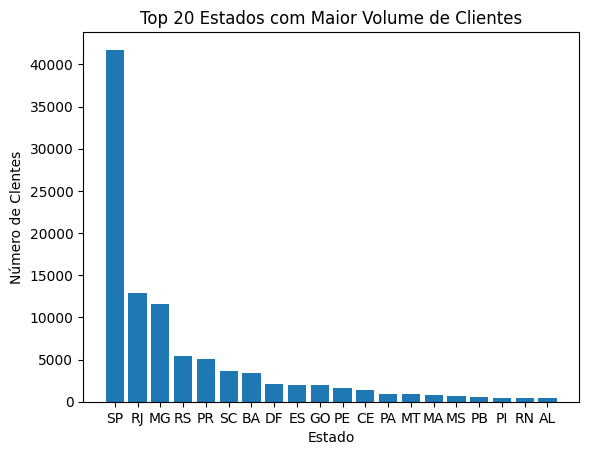

In [ ]:
top_estados = df_clientes["customer_state"].value_counts().head(20)

plt.figure()

plt.bar(top_estados.index, top_estados.values)

plt.title("Top 20 Estados com Maior Volume de Clientes")
plt.xlabel("Estado")
plt.ylabel("Número de Clentes")

plt.show()

## Base de Dados IBGE

> A base do IBGE do Censo de 2022 contém registros de 5.570 municípios. Diferente da base da Olist, este conjunto de dados não apresenta valores nulos ou duplicatas, o que facilita a etapa de tratamento. Foi observado que metade das cidades são de pequeno porte, evidenciado pelo indicador de mediana de 11.065 habitantes.


> Através da coluna Município, identificamos que os dados seguem o padrão "Nome da Cidade - UF", como visto em registros como "Alta Floresta D'Oeste - RO". Essa estrutura exigirá uma etapa de limpeza para separar o nome da cidade da sigla do estado, permitindo o cruzamento com os dados de vendas. Outro ponto relevante é que todos os campos foram carregados originalmente como texto (object), o que demandou a conversão da coluna de população para um formato numérico, possibilitando a realização de cálculos estatísticos.



In [ ]:
url_sidra = "https://apisidra.ibge.gov.br/values/t/4709/n6/all/v/93/p/2022" #Fixando o ano no lugar de all para evitar se se utilizar outros anos https://apisidra.ibge.gov.br/values/t/4709/n6/all/v/93/p/all
response = requests.get(url_sidra)

# verificação de sucesso de request
if response.status_code == 200:
    print("Requisição feita com sucesso")

    dados_crus = response.json() # Convertendo a resposta para uma lista
else:
    print(f"Erro ao acessar a API. Código de status: {response.status_code}")




Requisição feita com sucesso


Entendendo o formato de retorno da API

In [ ]:
for i in range(4):
  print(f"\n>> CONTEÚDO DA LINHA {i}:")
  print(dados_crus[i])


>> CONTEÚDO DA LINHA 0:
{'NC': 'Nível Territorial (Código)', 'NN': 'Nível Territorial', 'MC': 'Unidade de Medida (Código)', 'MN': 'Unidade de Medida', 'V': 'Valor', 'D1C': 'Município (Código)', 'D1N': 'Município', 'D2C': 'Variável (Código)', 'D2N': 'Variável', 'D3C': 'Ano (Código)', 'D3N': 'Ano'}

>> CONTEÚDO DA LINHA 1:
{'NC': '6', 'NN': 'Município', 'MC': '45', 'MN': 'Pessoas', 'V': '21494', 'D1C': '1100015', 'D1N': "Alta Floresta D'Oeste - RO", 'D2C': '93', 'D2N': 'População residente', 'D3C': '2022', 'D3N': '2022'}

>> CONTEÚDO DA LINHA 2:
{'NC': '6', 'NN': 'Município', 'MC': '45', 'MN': 'Pessoas', 'V': '96833', 'D1C': '1100023', 'D1N': 'Ariquemes - RO', 'D2C': '93', 'D2N': 'População residente', 'D3C': '2022', 'D3N': '2022'}

>> CONTEÚDO DA LINHA 3:
{'NC': '6', 'NN': 'Município', 'MC': '45', 'MN': 'Pessoas', 'V': '5351', 'D1C': '1100031', 'D1N': 'Cabixi - RO', 'D2C': '93', 'D2N': 'População residente', 'D3C': '2022', 'D3N': '2022'}


Convertendo para trabalhar com pandas

In [ ]:
# Cria a tabela ignorando a linha 0 que tem os metadados
df_ibge = pd.DataFrame(dados_crus[1:])

# Usa os valores da linha 0 para nomear as colunas de forma legível
df_ibge.columns = dados_crus[0].values()


Entendendo os dados

In [ ]:
# Obtendo informações sobre o retorno
print("\n>> Info: IBGE")
df_ibge.info()


>> Info: IBGE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Nível Territorial (Código)  5570 non-null   object
 1   Nível Territorial           5570 non-null   object
 2   Unidade de Medida (Código)  5570 non-null   object
 3   Unidade de Medida           5570 non-null   object
 4   Valor                       5570 non-null   object
 5   Município (Código)          5570 non-null   object
 6   Município                   5570 non-null   object
 7   Variável (Código)           5570 non-null   object
 8   Variável                    5570 non-null   object
 9   Ano (Código)                5570 non-null   object
 10  Ano                         5570 non-null   object
dtypes: object(11)
memory usage: 478.8+ KB


In [ ]:
print(">> Tabela do IBGE:")
display(df_ibge.head(3))

>> Tabela do IBGE:


,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Município (Código),Município,Variável (Código),Variável,Ano (Código),Ano
0,6,Município,45,Pessoas,21494,1100015,Alta Floresta D'Oeste - RO,93,População residente,2022,2022
1,6,Município,45,Pessoas,96833,1100023,Ariquemes - RO,93,População residente,2022,2022
2,6,Município,45,Pessoas,5351,1100031,Cabixi - RO,93,População residente,2022,2022


In [ ]:
print("\n>> Descrição: IBGE")
display(df_ibge.describe())


>> Descrição: IBGE


,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Município (Código),Município,Variável (Código),Variável,Ano (Código),Ano
count,5570,5570,5570,5570,5570,5570,5570,5570,5570,5570,5570
unique,1,1,1,1,5069,5570,5570,1,1,1,1
top,6,Município,45,Pessoas,5228,5300108,Brasília - DF,93,População residente,2022,2022
freq,5570,5570,5570,5570,4,1,1,5570,5570,5570,5570


Os dois trechos de código acima mostram que o formato do retorno da API para o campo 'Valor' está errado, pois está sendo retornado como uma string. Com isso, o describe apenas está contabilizando as ocorrências na API, sendo necessária uma conversão e a aplicação do describe posteriormente.

In [ ]:
# Fazendo a Conversão
df_ibge["Valor"] = pd.to_numeric(df_ibge["Valor"])
print(df_ibge["Valor"].dtype)

int64


In [ ]:
print("\n>> Descrição: IBGE")
# Aplicando a formatação de milhar e substituindo a vírgula americana pelo ponto brasileiro
display(df_ibge.describe().style.format(lambda x: f"{x:,.0f}".replace(",", ".")))


>> Descrição: IBGE


,Valor
count,5.570
mean,36.460
std,206.519
min,833
25%,5.228
50%,11.065
75%,24.427
max,11.451.999


In [ ]:
# Verificação de linhas duplicadas
print("\n>> Linhas duplicadas: IBGE")
display(df_ibge.duplicated().sum())


>> Linhas duplicadas: IBGE


np.int64(0)

In [ ]:
# Verificação de linhas Nulas
print("\n>> Nulos: IBGE")
display(df_ibge.isnull().sum())


>> Nulos: IBGE


,0
Nível Territorial (Código),0
Nível Territorial,0
Unidade de Medida (Código),0
Unidade de Medida,0
Valor,0
Município (Código),0
Município,0
Variável (Código),0
Variável,0
Ano (Código),0


# Tarefa 2: Limpeza, Modelagem e Consulta


## Tratamento dos dados


> A limpeza e padronização dos dados será feita em Python devido à simplicidade e à eficiência das funções nativas do próprio Python.



In [ ]:
# Realiza uma cópia para preservar dado
df_clientes_tratado = df_clientes.copy()
df_geoloc_tratado = df_geoloc.copy()
df_pedidos_tratado = df_pedidos.copy()

df_ibge_tratado = df_ibge.copy()


### Base **Olist**

Função desenvolvida com auxílio de IA para realizar a conversão de minúsculas, retirada de acentos e espaços extras

In [ ]:
def limpar_texto(texto):

  texto = str(texto).lower()

  texto = ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')

  return texto.strip()

In [ ]:
# remove geolocalizações duplicadas mantendo apenas o primeiro registro do CEP
df_geoloc_tratado = df_geoloc_tratado.drop_duplicates(subset=['geolocation_zip_code_prefix'], keep='first')

# remove clientes duplicados
df_clientes_tratado = df_clientes_tratado.drop_duplicates()

# realiza a limpeza e padronização das cidades
df_clientes_tratado['cidade_clean'] = df_clientes_tratado['customer_city'].apply(limpar_texto)


# Padronização de CEPs
df_geoloc_tratado['geolocation_zip_code_prefix'] = df_geoloc_tratado['geolocation_zip_code_prefix'].astype(str).str.zfill(5) # Converte para texto e põe zeros à esquerda
df_clientes_tratado['customer_zip_code_prefix'] = df_clientes_tratado['customer_zip_code_prefix'].astype(str).str.zfill(5) # Garante que SP não perca o zero inicial

# Converte texto para formato de data
df_pedidos_tratado['data_compra'] = pd.to_datetime(df_pedidos_tratado['order_purchase_timestamp'])

# Extrai 'Ano-Mês' já como texto para o gráfico
df_pedidos_tratado['ano_mes'] = df_pedidos_tratado['data_compra'].dt.to_period('M').astype(str)

# Extrai a hora exata da compra (0-23)
df_pedidos_tratado['hora_compra'] = df_pedidos_tratado['data_compra'].dt.hour

In [ ]:
display(df_clientes_tratado['cidade_clean'].head(5))
print("\n>> Linhas duplicadas: Geolocalização")
display(df_geoloc_tratado.duplicated().sum())

,cidade_clean
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas



>> Linhas duplicadas: Geolocalização


np.int64(0)

### Base **IBGE**

In [ ]:
# separa a cidade do estado no formato original do ibge
df_ibge_tratado[['nome_cidade', 'sigla_uf']] = df_ibge_tratado['Município'].str.split(' - ', expand=True)

# realiza a limpeza e padronização das cidades
df_ibge_tratado['cidade_clean'] = df_ibge_tratado['nome_cidade'].apply(limpar_texto)


In [ ]:
display(df_ibge_tratado[['nome_cidade', 'sigla_uf', 'cidade_clean']].head(5))

,nome_cidade,sigla_uf,cidade_clean
0,Alta Floresta D'Oeste,RO,alta floresta d'oeste
1,Ariquemes,RO,ariquemes
2,Cabixi,RO,cabixi
3,Cacoal,RO,cacoal
4,Cerejeiras,RO,cerejeiras


## Junção e Consolidação dos Dados


> Utilizei a consulta direta em memória por ser mais rápida e mais eficiente devido ao volume de dados utilizado no projeto. Como os dados já estavam carregados e tratados em DataFrames no Pandas, não foi necessário criar tabelas físicas no banco de dados. Dessa forma, foi possível registrar os DataFrames no DuckDB e realizar as consultas SQL diretamente em memória, tornando o processo mais simples.



In [ ]:


con = duckdb.connect()

# Registrando os DataFrames
con.register("clientes", df_clientes_tratado)
con.register("pedidos", df_pedidos)
con.register("ibge", df_ibge_tratado)

df_base_consolidada = con.execute("""

SELECT
    i.nome_cidade AS cidade,
    i.sigla_uf AS uf,
    i.Valor AS populacao,
    COUNT(DISTINCT c.customer_unique_id) AS clientes_unicos,
    COUNT(o.order_id) AS total_pedidos
FROM ibge i

LEFT JOIN clientes c
    ON i.cidade_clean = c.cidade_clean
    AND i.sigla_uf = UPPER(c.customer_state)
LEFT JOIN pedidos o
    ON c.customer_id = o.customer_id

GROUP BY i.nome_cidade, i.sigla_uf, i.Valor
ORDER BY total_pedidos DESC

""").df()

# Tratando os nulos
df_base_consolidada[['clientes_unicos', 'total_pedidos']] = df_base_consolidada[['clientes_unicos', 'total_pedidos']].fillna(0)

In [ ]:
print(f"Total de cidades na base consolidada: {len(df_base_consolidada)}")
df_base_consolidada.head()

Total de cidades na base consolidada: 5570


,cidade,uf,populacao,clientes_unicos,total_pedidos
0,São Paulo,SP,11451999,14984,15540
1,Rio de Janeiro,RJ,6211223,6620,6882
2,Belo Horizonte,MG,2315560,2672,2773
3,Brasília,DF,2817381,2069,2131
4,Curitiba,PR,1773718,1465,1521


# Tarefa 3: Análise de Qualidade de Dados


> Após a análise, observou-se uma perda de aproximadamente 0,73% de registros que não foram vinculados entre as bases. Isso possivelmente ocorre em casos como o exemplo "mogi-guacu", que apresenta diferenças de grafia em relação ao padrão do IBGE, como uso de hífen, variações na escrita nomes compostos ou até erros de grafía.


> Uma possível solução para reduzir esse problema seria realizar o cruzamento utilizando CEP, pois se trata de um identificador numérico padronizado, menos suscetível a erros de digitação.







Identifica quais cidades da base de clientes não encontraram correspondência no IBGE

In [ ]:
df_cidades_sem_match = con.execute("""

SELECT
    c.cidade_clean,
    UPPER(c.customer_state) AS uf,
    COUNT(DISTINCT c.customer_unique_id) AS clientes

FROM clientes c

LEFT JOIN ibge i
    ON c.cidade_clean = i.cidade_clean
    AND UPPER(c.customer_state) = i.sigla_uf

WHERE i.cidade_clean IS NULL

GROUP BY
    c.cidade_clean,
    uf

ORDER BY clientes DESC

""").df()

display(df_cidades_sem_match.head(100))

,cidade_clean,uf,clientes
0,mogi-guacu,SP,88
1,piumhii,MG,28
2,santana do livramento,RS,20
3,bonfim paulista,SP,18
4,parati,RJ,13
...,...,...,...
95,caraiba,PE,2
96,palmeirinha,PR,2
97,luizlandia do oeste,MG,2
98,couto de magalhaes,TO,2


Realiza a verificação de qualidade da junção (Join) com a base do IBGE,
retornando o volume exato de correspondências bem-sucedidas (match) e as falhas.

In [ ]:
df_qualidade = con.execute("""

SELECT
    COUNT(DISTINCT c.customer_unique_id) AS total_clientes,

    COUNT(DISTINCT CASE WHEN i.cidade_clean IS NOT NULL
        THEN c.customer_unique_id END) AS clientes_com_match,

    COUNT(DISTINCT CASE WHEN i.cidade_clean IS NULL
        THEN c.customer_unique_id END) AS clientes_sem_match

FROM clientes c

LEFT JOIN ibge i
    ON c.cidade_clean = i.cidade_clean
    AND UPPER(c.customer_state) = i.sigla_uf

""").df()

In [ ]:
total = df_qualidade['total_clientes'][0]
perda = df_qualidade['clientes_sem_match'][0]

percentual_perda = (perda / total) * 100

print(f"Total de clientes: {total}")
print(f"Clientes sem correspondência: {perda}")
print(f"Percentual de perda: {percentual_perda:.2f}%")

Total de clientes: 96096
Clientes sem correspondência: 703
Percentual de perda: 0.73%


# Tarefa 4: Análise de Penetração e Potencial de Crescimento

> O resultado indica que as cidades com maior potencial de crescimento estão concentradas no Norte e Nordeste do Brasil. São José de Ribamar se destaca como a maior oportunidade — com 245 mil habitantes e apenas 14 clientes, apresenta a menor penetração do ranking. Manaus aparece logo atrás com penetração igualmente baixa, porém com um mercado ainda maior de 2,1 milhões de habitantes. As demais cidades, como Marabá, Parauapebas e Juazeiro do Norte, reforçam que a Olist ainda tem presença mínima no interior do Norte e Nordeste.

Utilizarei a seguinte métrica Clientes / População

In [ ]:
df_base_consolidada["penetracao_mercado"] = (df_base_consolidada["clientes_unicos"] / df_base_consolidada["populacao"])

In [ ]:
df_base_consolidada.head()

,cidade,uf,populacao,clientes_unicos,total_pedidos,penetracao_mercado
0,São Paulo,SP,11451999,14984,15540,0.001308
1,Rio de Janeiro,RJ,6211223,6620,6882,0.001066
2,Belo Horizonte,MG,2315560,2672,2773,0.001154
3,Brasília,DF,2817381,2069,2131,0.000734
4,Curitiba,PR,1773718,1465,1521,0.000826


Aplicar filtro e exibir informações

In [ ]:
# Cidades com população maior que 200000
df_cidades_grandes = df_base_consolidada[
    df_base_consolidada["populacao"] > 200000
]

# Busca as 10 cidades com a menor penetração diretamente
df_oportunidades = df_cidades_grandes.nsmallest(10, 'penetracao_mercado')


display(df_oportunidades[['cidade', 'uf', 'populacao', 'clientes_unicos', 'penetracao_mercado']])

,cidade,uf,populacao,clientes_unicos,penetracao_mercado
685,São José de Ribamar,MA,244579,14,0.000057
98,Manaus,AM,2063689,135,0.000065
502,Marabá,PA,266533,22,0.000083
436,Parauapebas,PA,267836,24,0.000090
360,Caucaia,CE,355679,35,0.000098
476,Águas Lindas de Goiás,GO,225693,23,0.000102
517,Cabo de Santo Agostinho,PE,203440,21,0.000103
289,Boa Vista,RR,413486,44,0.000106
371,Juazeiro do Norte,CE,286120,34,0.000119
412,Arapiraca,AL,234696,28,0.000119


Gráfico indicatívo de oportunidade

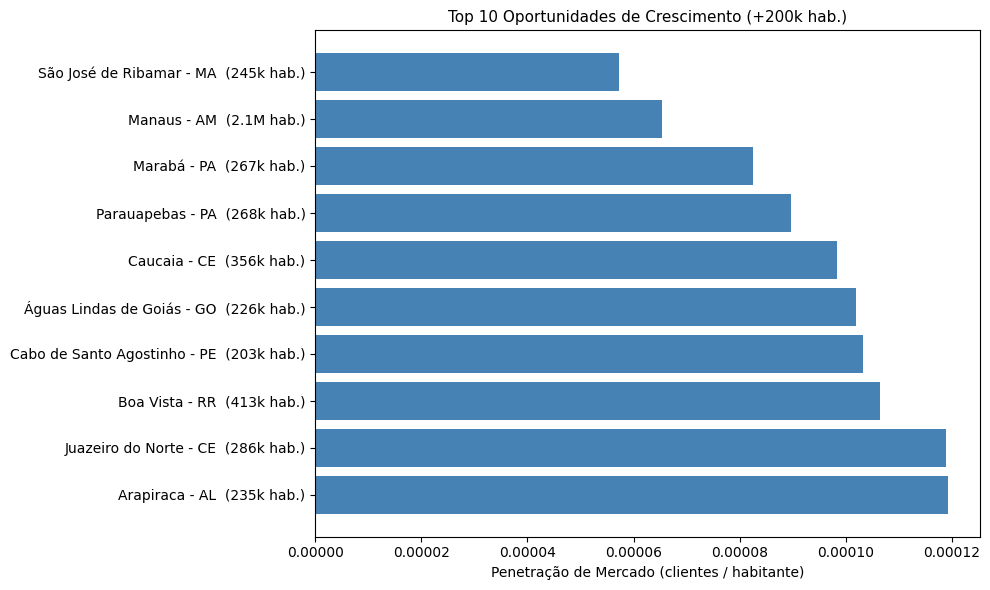

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Ordena do maior potencial (menor penetração) para o menor
df_plot = df_oportunidades.sort_values('penetracao_mercado', ascending=True)

labels = (
    df_plot['cidade'] + ' - ' + df_plot['uf'] +
    '  (' + df_plot['populacao'].apply(lambda x: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k') + ' hab.)'
)

ax.barh(labels, df_plot['penetracao_mercado'], color='steelblue')
ax.set_xlabel('Penetração de Mercado (clientes / habitante)')
ax.set_title('Top 10 Oportunidades de Crescimento (+200k hab.)', fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Tarefa 5: Visualização Geoespacial e Exploração Livre

> A partir da análise feita, observa-se que os clientes estão concentrados no eixo costeiro do Sudeste, com o interior do país representando uma oportunidade clara de expansão. A plataforma cresceu consistentemente até 2017, com pico na Black Friday, e o comportamento de compra se concentra entre 10h e 22h, com maior volume no meio da tarde — indicando as faixas horárias com maior efetividade para veiculação de anúncios.

## Mapa de Calor — Dispersão Geográfica de Clientes
> Mostra à diretoria a concentração territorial da base, evidenciando dependência do Sudeste e oportunidades de expansão nas regiões com baixa ou nenhuma presença.


In [ ]:
from folium.plugins import HeatMap

con.register('tabela_geolocalizacao', df_geoloc_tratado)

# SQL puxando as coordenadas (Já usando o df_clientes_tratado)
df_mapa_coords = con.execute("""
    SELECT
        g.geolocation_lat,
        g.geolocation_lng
    FROM df_clientes_tratado c
    INNER JOIN tabela_geolocalizacao g
        ON c.customer_zip_code_prefix = g.geolocation_zip_code_prefix
    WHERE g.geolocation_lat IS NOT NULL
    GROUP BY 1, 2
""").df()

# Criação do Mapa de Calor
mapa_brasil = folium.Map(location=[-15.78, -47.93], zoom_start=4)
dados_mapa = df_mapa_coords.values.tolist()              # Converte as colunas para o formato de lista que o Folium exige

HeatMap(dados_mapa, radius=8, blur=5).add_to(mapa_brasil)

mapa_brasil

## Evolução Mensal de Pedidos

> Mostra ao time comercial a tendência de crescimento da plataforma e identifica picos sazonais como a Black Friday, orientando o planejamento de estoque e campanhas.

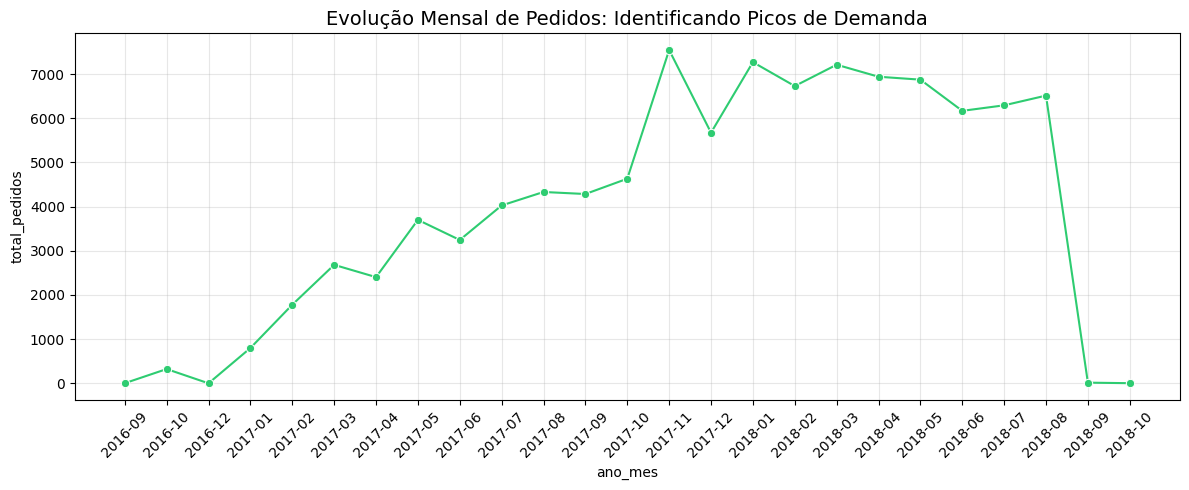

In [ ]:
# Agrupa os meses e conta o total de pedidos
vendas_mensais = df_pedidos_tratado.groupby('ano_mes').size().reset_index(name='total_pedidos')

# Criar o Gráfico de Linhas
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=vendas_mensais,
    x='ano_mes',
    y='total_pedidos',
    marker='o',
    color='#2ecc71'
)

plt.title('Evolução Mensal de Pedidos: Identificando Picos de Demanda', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Volume de Pedidos por Hora do Dia
> Mostra ao marketing os horários de maior volume de compras, permitindo reorganizar os horários de veiculação de anúncios e campanhas para maximizar a conversão.

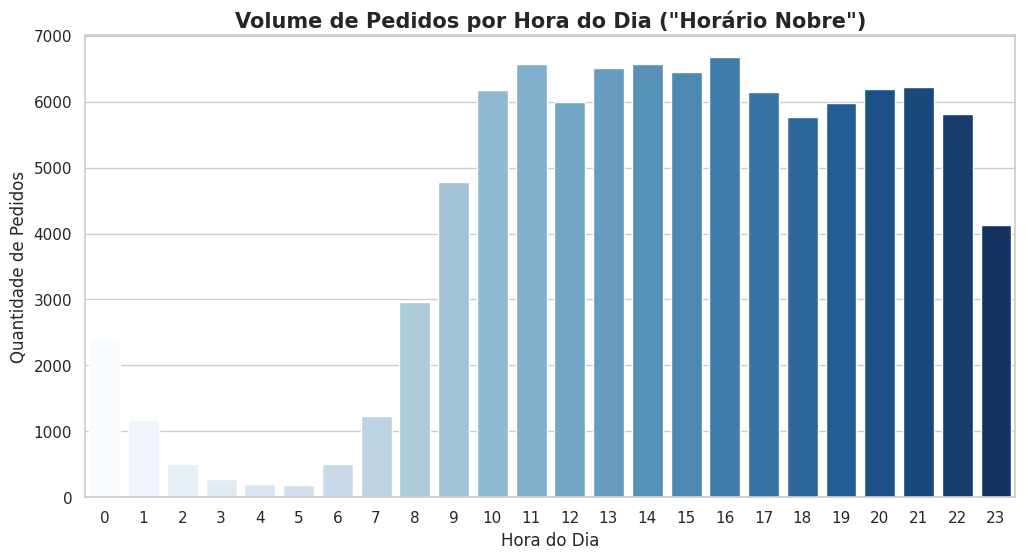

In [ ]:
vendas_por_hora = df_pedidos_tratado.groupby('hora_compra').size().reset_index(name='total_pedidos')

# Criar o Gráfico de Barras
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=vendas_por_hora,
    x='hora_compra',
    y='total_pedidos',
    palette='Blues',
    hue='hora_compra',
    legend=False
)

plt.title('Volume de Pedidos por Hora do Dia ("Horário Nobre")', fontsize=15, weight='bold')
plt.xlabel('Hora do Dia', fontsize=12)
plt.ylabel('Quantidade de Pedidos', fontsize=12)

plt.show()

# Uso de Inteligência Artificial (IA)

> O uso de IA foi implementado com o objetivo de acelerar o aprendizado sobre novas tecnologias, como a biblioteca Folium para a criação de mapas de calor (Heatmaps). Além disso, a ferramenta auxiliou na formatação estética de gráficos e no refinamento de consultas SQL complexas. É importante ressaltar que todo o código sugerido passou por um processo rigoroso de verificação, análise e validação técnica antes de sua implementação final no projeto.
